# Foundations of Time Series Analysis

## Datasets and Setup

### Dataset Choice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

# ══════════════════════════════════════════════════════════════════════════
# Dataset A — Air Passengers (ARIMA / SARIMA)
# ══════════════════════════════════════════════════════════════════════════
from statsmodels.datasets import get_rdataset

air = get_rdataset("AirPassengers", "datasets").data
air.columns = ["time", "passengers"]
# Reconstruct a proper DatetimeIndex from the fractional year column
air["date"] = pd.date_range(start="1949-01", periods=len(air), freq="MS")
air = air.set_index("date")["passengers"].rename("passengers")

print("=== Air Passengers ===")
print(f"  Observations : {len(air)}")
print(f"  Period       : {air.index[0].strftime('%b %Y')} – {air.index[-1].strftime('%b %Y')}")
print(f"  Frequency    : Monthly")
print(f"  Min / Max    : {air.min()} / {air.max()} thousand passengers")
print(f"\n  First 12 observations:")
print(air.head(12).to_string())

# ══════════════════════════════════════════════════════════════════════════
# Dataset B — Appliance Energy (ML forecasting)
# ══════════════════════════════════════════════════════════════════════════
energy_url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases"
    "/00374/energydata_complete.csv"
)
df_energy = pd.read_csv(energy_url, parse_dates=["date"])
df_energy = df_energy.set_index("date").sort_index()

print("\n=== Appliance Energy ===")
print(f"  Observations : {len(df_energy):,}")
print(f"  Period       : {df_energy.index[0]} – {df_energy.index[-1]}")
print(f"  Frequency    : 10-minute intervals")
print(f"  Target       : Appliances (Wh), range [{df_energy['Appliances'].min()}, "
      f"{df_energy['Appliances'].max()}]")
print(f"  Covariates   : {df_energy.shape[1] - 1} temperature/humidity/weather features")

=== Air Passengers ===
  Observations : 144
  Period       : Jan 1949 – Dec 1960
  Frequency    : Monthly
  Min / Max    : 104 / 622 thousand passengers

  First 12 observations:
date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
1949-06-01    135
1949-07-01    148
1949-08-01    148
1949-09-01    136
1949-10-01    119
1949-11-01    104
1949-12-01    118

=== Appliance Energy ===
  Observations : 19,735
  Period       : 2016-01-11 17:00:00 – 2016-05-27 18:00:00
  Frequency    : 10-minute intervals
  Target       : Appliances (Wh), range [10, 1080]
  Covariates   : 27 temperature/humidity/weather features


### Preprocessing

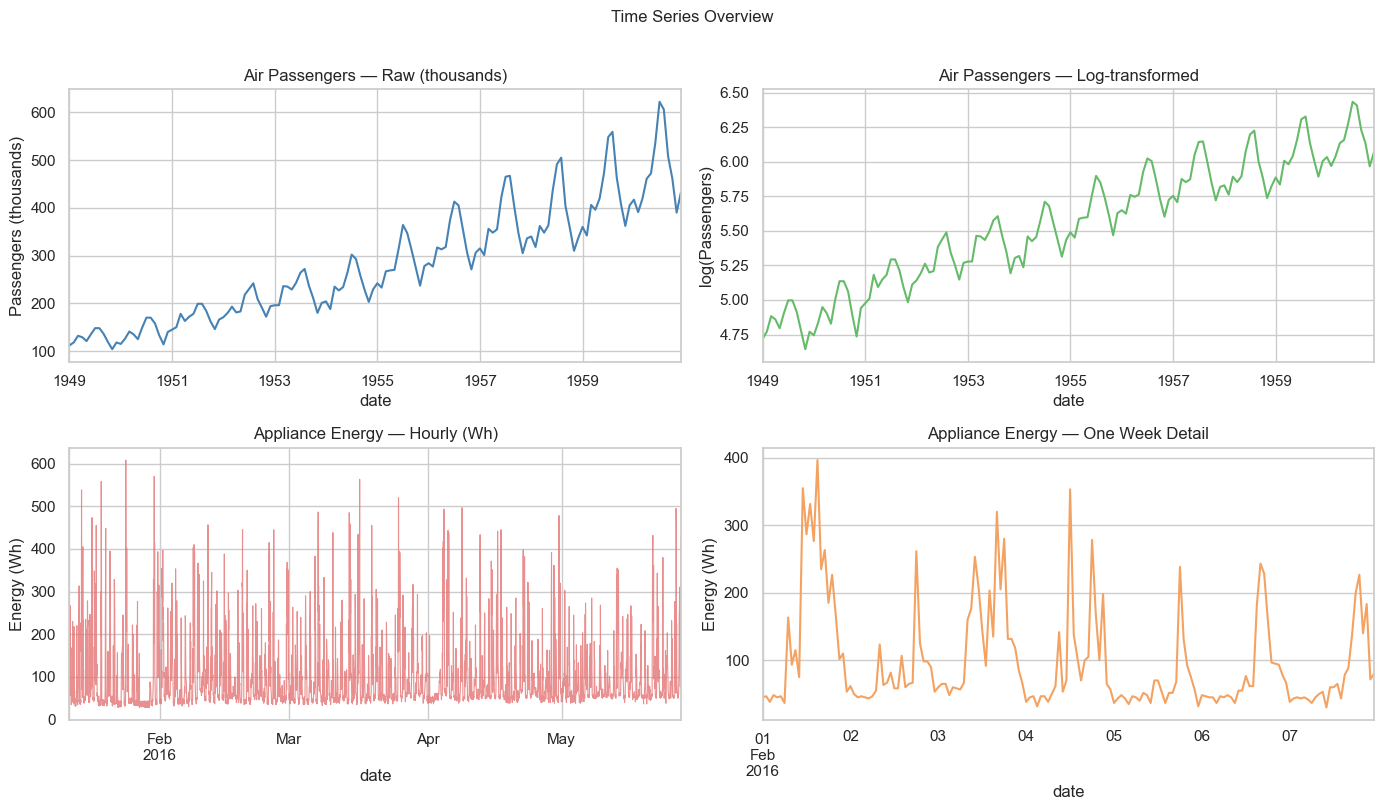

In [2]:
# ── Log-transform for Air Passengers (multiplicative → additive seasonality) ─
log_air = np.log(air)

# ── Resample energy data to hourly for manageable modelling ───────────────
energy_hourly = df_energy["Appliances"].resample("1h").mean()

# ── Visualise both raw series ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

air.plot(ax=axes[0, 0], color="steelblue", lw=1.5)
axes[0, 0].set_title("Air Passengers — Raw (thousands)")
axes[0, 0].set_ylabel("Passengers (thousands)")

log_air.plot(ax=axes[0, 1], color="#66BB6A", lw=1.5)
axes[0, 1].set_title("Air Passengers — Log-transformed")
axes[0, 1].set_ylabel("log(Passengers)")

energy_hourly.plot(ax=axes[1, 0], color="#E57373", lw=0.8, alpha=0.8)
axes[1, 0].set_title("Appliance Energy — Hourly (Wh)")
axes[1, 0].set_ylabel("Energy (Wh)")

# Plot one week for detail
energy_week = energy_hourly["2016-02-01":"2016-02-07"]
energy_week.plot(ax=axes[1, 1], color="#F4A261", lw=1.5)
axes[1, 1].set_title("Appliance Energy — One Week Detail")
axes[1, 1].set_ylabel("Energy (Wh)")

plt.suptitle("Time Series Overview", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch02_overview.png", dpi=150, bbox_inches="tight")
plt.show()

### Classical Decomposition

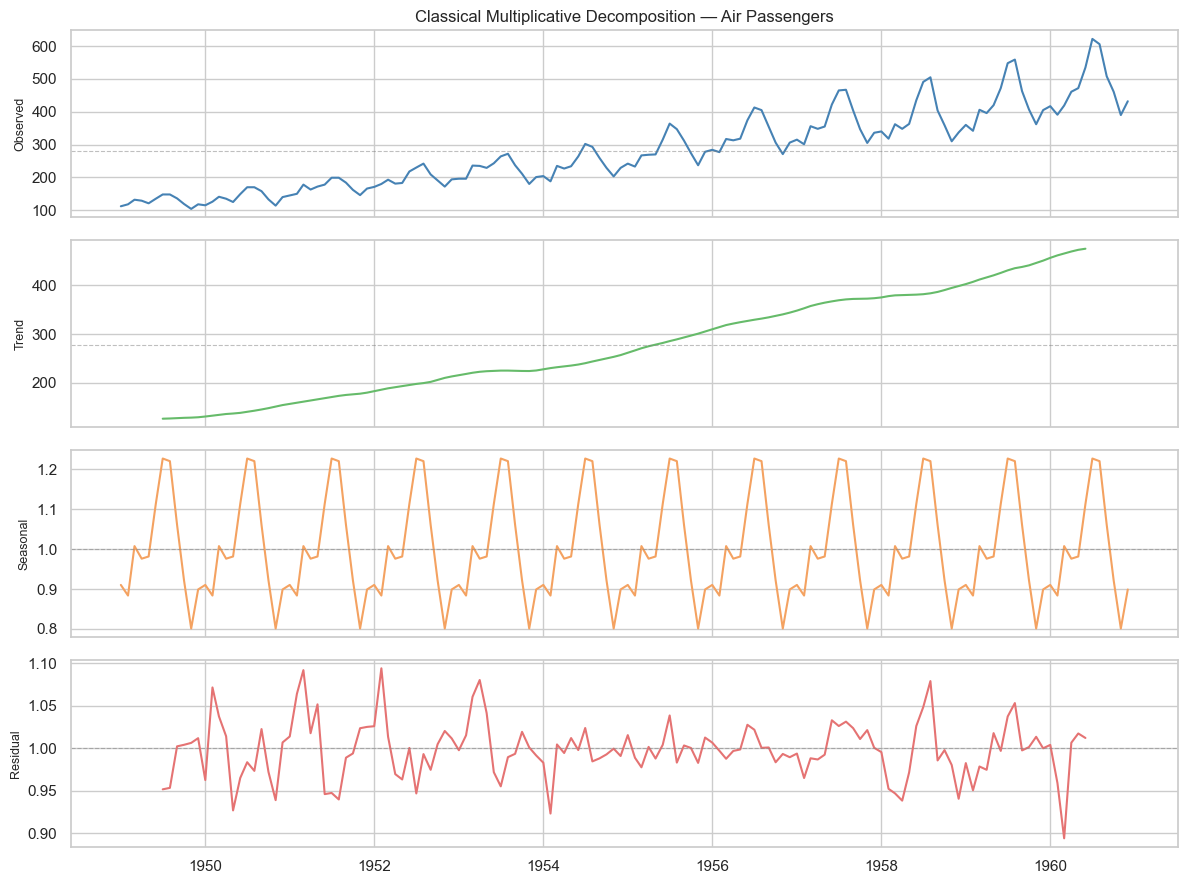

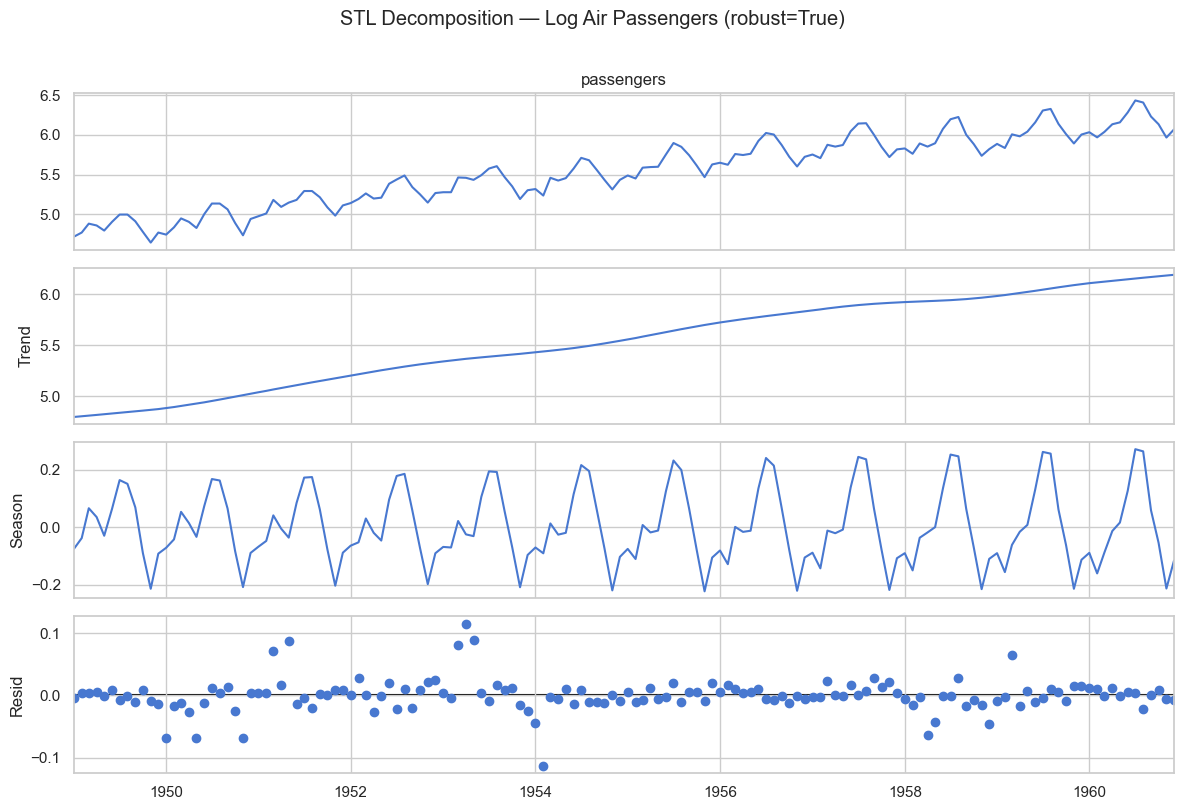

STL Seasonal strength : 0.9593  (0=none, 1=perfect)
STL Trend strength    : 0.9961  (0=none, 1=perfect)


In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

# ── Classical multiplicative decomposition ────────────────────────────────
decomp_mult = seasonal_decompose(air, model="multiplicative", period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
components = [
    (air,                   "Observed",  "steelblue"),
    (decomp_mult.trend,     "Trend",     "#66BB6A"),
    (decomp_mult.seasonal,  "Seasonal",  "#F4A261"),
    (decomp_mult.resid,     "Residual",  "#E57373"),
]
for ax, (series, label, color) in zip(axes, components):
    ax.plot(series, color=color, lw=1.5)
    ax.set_ylabel(label, fontsize=9)
    ax.axhline(1 if label in ("Seasonal", "Residual") else series.mean(),
               color="gray", lw=0.8, linestyle="--", alpha=0.5)

axes[0].set_title("Classical Multiplicative Decomposition — Air Passengers")
plt.tight_layout()
plt.savefig(FIGURES / "ch02_decomp_classical.png", dpi=150, bbox_inches="tight")
plt.show()

# ── STL decomposition (robust to outliers) ────────────────────────────────
stl = STL(log_air, period=12, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle("STL Decomposition — Log Air Passengers (robust=True)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch02_decomp_stl.png", dpi=150, bbox_inches="tight")
plt.show()

# Seasonal strength metric
var_resid = np.var(stl_result.resid)
var_seas_plus_resid = np.var(stl_result.seasonal + stl_result.resid)
seasonal_strength = max(0, 1 - var_resid / var_seas_plus_resid)

var_trend_plus_resid = np.var(stl_result.trend + stl_result.resid)
trend_strength = max(0, 1 - var_resid / var_trend_plus_resid)

print(f"STL Seasonal strength : {seasonal_strength:.4f}  (0=none, 1=perfect)")
print(f"STL Trend strength    : {trend_strength:.4f}  (0=none, 1=perfect)")

## Stationarity and Transformations

### Augmented Dickey-Fuller Test

In [4]:
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\n{'─'*55}")
    print(f"  ADF Test: {label}")
    print(f"{'─'*55}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.6f}")
    print(f"  Lags used     : {result[2]}")
    for pct, cv in result[4].items():
        print(f"  Critical ({pct})  : {cv:.4f}")
    conclusion = "STATIONARY ✓" if result[1] < 0.05 else "NON-STATIONARY ✗"
    print(f"  Conclusion    : {conclusion} (α=0.05)")

# ── Test raw, log, first-differenced, and log-differenced series ──────────
adf_report(air,               "Raw passengers")
adf_report(log_air,           "Log passengers")

log_air_d1   = log_air.diff().dropna()
adf_report(log_air_d1,        "Log passengers — 1st diff")

log_air_d1_D1 = log_air_d1.diff(12).dropna()
adf_report(log_air_d1_D1,     "Log passengers — 1st diff + seasonal diff(12)")


───────────────────────────────────────────────────────
  ADF Test: Raw passengers
───────────────────────────────────────────────────────
  ADF Statistic : 0.8154
  p-value       : 0.991880
  Lags used     : 13
  Critical (1%)  : -3.4817
  Critical (5%)  : -2.8840
  Critical (10%)  : -2.5788
  Conclusion    : NON-STATIONARY ✗ (α=0.05)

───────────────────────────────────────────────────────
  ADF Test: Log passengers
───────────────────────────────────────────────────────
  ADF Statistic : -1.7170
  p-value       : 0.422367
  Lags used     : 13
  Critical (1%)  : -3.4817
  Critical (5%)  : -2.8840
  Critical (10%)  : -2.5788
  Conclusion    : NON-STATIONARY ✗ (α=0.05)

───────────────────────────────────────────────────────
  ADF Test: Log passengers — 1st diff
───────────────────────────────────────────────────────
  ADF Statistic : -2.7171
  p-value       : 0.071121
  Lags used     : 14
  Critical (1%)  : -3.4825
  Critical (5%)  : -2.8844
  Critical (10%)  : -2.5790
  Conclusion  

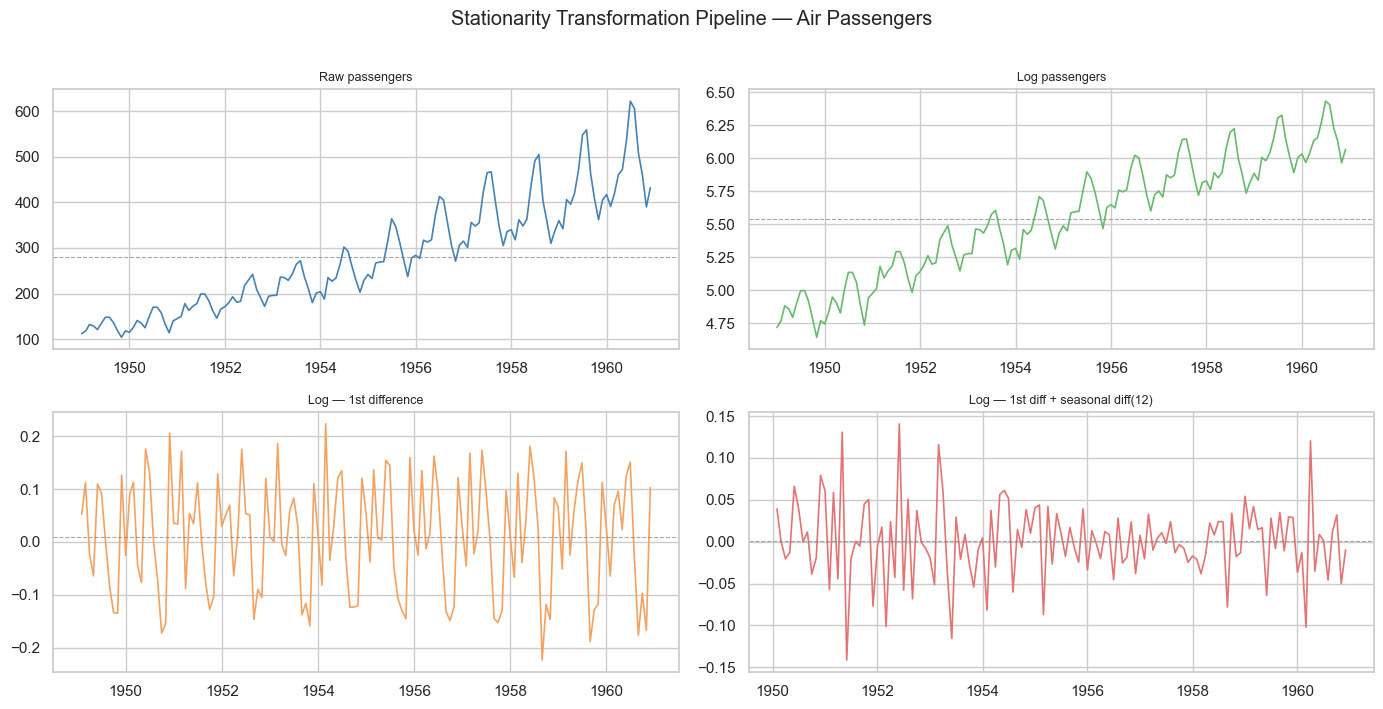

In [5]:
# ── Visualise the transformation pipeline ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
series_list = [
    (air,           "Raw passengers",                         "steelblue"),
    (log_air,       "Log passengers",                         "#66BB6A"),
    (log_air_d1,    "Log — 1st difference",                   "#F4A261"),
    (log_air_d1_D1, "Log — 1st diff + seasonal diff(12)",     "#E57373"),
]
for ax, (s, title, color) in zip(axes.flatten(), series_list):
    ax.plot(s, color=color, lw=1.2)
    ax.axhline(s.mean(), color="gray", lw=0.8, linestyle="--", alpha=0.7)
    ax.set_title(title, fontsize=9)
plt.suptitle("Stationarity Transformation Pipeline — Air Passengers", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch02_stationarity.png", dpi=150, bbox_inches="tight")
plt.show()

## Autocorrelation and Partial Autocorrelation

### Definitions

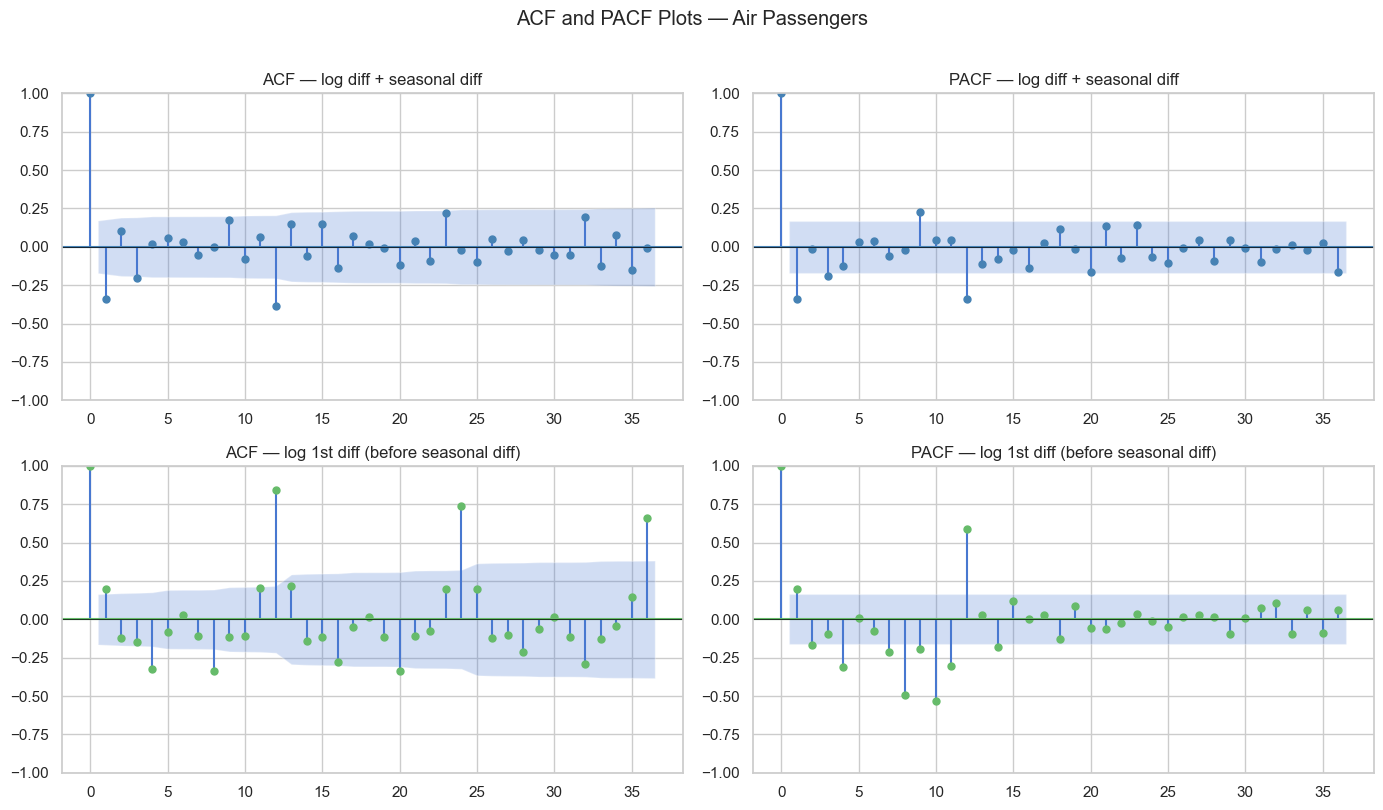

Ljung-Box test on doubly-differenced series:
    lb_stat  lb_pvalue
6   23.2709     0.0007
12  51.4728     0.0000
18  62.4421     0.0000
24  74.2652     0.0000


In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(log_air_d1_D1,  lags=36, ax=axes[0, 0], color="steelblue",
         title="ACF — log diff + seasonal diff")
plot_pacf(log_air_d1_D1, lags=36, ax=axes[0, 1], color="steelblue",
          title="PACF — log diff + seasonal diff")

# Also show on raw first-difference for comparison
plot_acf(log_air_d1,  lags=36, ax=axes[1, 0], color="#66BB6A",
         title="ACF — log 1st diff (before seasonal diff)")
plot_pacf(log_air_d1, lags=36, ax=axes[1, 1], color="#66BB6A",
          title="PACF — log 1st diff (before seasonal diff)")

for ax in axes.flatten():
    ax.axhline(0, color="black", lw=0.5)

plt.suptitle("ACF and PACF Plots — Air Passengers", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch02_acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Ljung-Box test for residual autocorrelation ───────────────────────────
from statsmodels.stats.diagnostic import acorr_ljungbox
lb = acorr_ljungbox(log_air_d1_D1, lags=[6, 12, 18, 24], return_df=True)
print("Ljung-Box test on doubly-differenced series:")
print(lb.round(4).to_string())